<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Serpiente_y_escaleras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **Matriz Fundamental** </span>

## <span style="color:blue;"> **Serpiente y escaleras** </span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Analizar el juego de serpientes y escaleras mediante técnicas analíticas (con CM) y de simulación para estimar el número promedio de tiradas necesarias para finalizar el juego.

Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

Resolver a detalle.

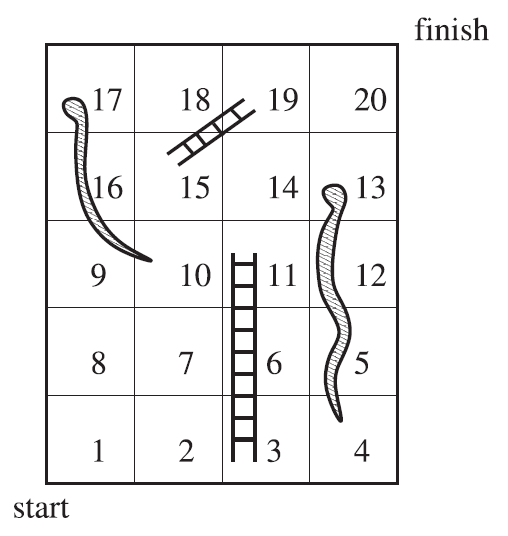

<span style="color:red;"> **Solución Analítica:** </span>
Observemos que esta matriz de transición P tiene:

* Estados transitorios: casillas $1$ a $19$ (juego continúa)
* Estado absorbente: casilla 20 (juego termina)

El juego comienza en la casilla 1

Hallamos la matriz de transición para el juego de serpientes y escaleras:

Para cada estado transitorio $i$ $(1 - 19)$ calculamos la probabilidad de transición a cualquier estado $j$ .

Sea P la matriz de transición de $20×20$, donde:

· $P_{i,j}$ = probabilidad de ir de la casilla i a la j .
· Para el estado absorbente: $P_{20,20} = 1$ .

Probabilidades:

Para una casilla i , los posibles resultados del dado son 1, 2, 3, 4, 5, 6 (cada uno con probabilidad $\frac{1}{6}$ ).

El destino tentativo es:

$destino_{tentativo}$ = $i + dado$

Si $destino_{tentativo}$ $\geq 20 , entonces \quad j = 20$ (absorción).

A ese destino tentativo se le aplica la regla de serpiente/escalera si existe.

In [120]:
import numpy as np
import sympy as sp
from sympy import Matrix , init_printing
import matplotlib.pyplot as plt
import random

In [121]:
#configuracion del tablero del juego
n = 20
dado = 6

# Saltos: escaleras y serpientes
salto = {3: 11, 15: 19, 13: 4, 17: 10}

In [122]:
# Matriz de transición
P = np.zeros((n,n))

for i in range(1,n+1):

    # Estado absorbente
    if i == 20:
        P[i-1,i-1] = 1
        continue

    for d in range(1,7):

        j = i + d

        # Si se pasa de 20, permanece igual
        # Si se pasa, permanece igual corregi esta parte debido a que se
        # estaba generando un bucle debido aque el jugador no avanzaba y desperdicia turno
        if j > 20:
            j = 20

        # Aplicar serpiente o escalera
        j = salto.get(j,j)

        P[i-1,j-1] += 1/6

In [123]:
# Obtener la matriz
print("Matriz de transición:")
sp.Matrix(P)

Matriz de transición:


Matrix([
[0.0, 0.166666666666667, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0,               0.0, 0.1666



De lo anterior la matriz de transición $P$ es de tamaño $20 \times 20$, donde $P_{ij}$ es la probabilidad de ir de la casilla $i$ a la casilla $j$:

$$
P = \begin{bmatrix}
0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{3} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{3} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{3} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{3} & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{2} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{2}{3} & \frac{1}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{5}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

Extraemos la submatriz Q (transitorios)

La matriz completa $P(20×20)$ se particiona:

P =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}

Donde:

* $Q (19×19)$: transiciones entre estados transitorios (casillas 1 a 19).
* $R (19×1)$: transiciones al estado absorbente (20).


Calculamos el tiempo esperado de absorción

Para una cadena absorbente, el vector $t$ de tiempos esperados desde cada estado transitorio es:

$t = (I - Q)^{-1} \cdot \mathbf{1}$

*  $I$ = matriz identidad $(19×19)$.
* $\mathbf{1}$ = vector columna de 19 unos.
· $t_i$ = número esperado de pasos para ser absorbido (llegar a 20) empezando en la casilla $i$.

El valor que nos interesa es $t_1$ (empezando en casilla 1).

Construimos Q y resolvemos:

$I - Q$ es:

$$
I - Q =
\begin{pmatrix}
1 - Q_{1,1} & -Q_{1,2} & \cdots & -Q_{1,19} \\
-Q_{2,1} & 1 - Q_{2,2} & \cdots & -Q_{2,19} \\
\vdots & \vdots & \ddots & \vdots \\
-Q_{19,1} & -Q_{19,2} & \cdots & 1 - Q_{19,19}
\end{pmatrix}
$$

Luego invertimos esta matriz y multiplicamos por el vector de unos.


In [124]:
Q = P[:19, :19]           # submatriz transitoria
sp.Matrix(Q)

Matrix([
[0.0, 0.166666666666667, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0],
[0.0,               0.0, 0.0,               0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.1666

In [125]:
I = np.eye(19)   # Matriz identidad

In [126]:
# Matriz fundamental tambien se puede donatar con F
N = np.linalg.inv(I - Q)
sp.Matrix(N)

Matrix([
[1.0, 0.166666666666667, 0.0,  0.668975723064831,  0.305940398288583,  0.356930464670013,  0.416418875448349,   0.31915535468974,  0.344570136026919, 0.706598709071859,  0.602713434143688,  0.457731162341761, 0.0,  0.405128132712328, 0.0, 0.362028573044939, 0.0, 0.204147978016505, 0.581341043011721],
[0.0,               1.0, 0.0,  0.647471733083607,  0.274578622180601,  0.320341725877368,  0.373732013523596,  0.436020682444195,  0.342024129518228, 0.700619124603555,  0.574552716357924,  0.457881732054144, 0.0,  0.418516397496341, 0.0, 0.358594995085327, 0.0, 0.205832187439302, 0.579422946675194],
[0.0,               0.0, 1.0,  0.656503924602706,  0.276083987433784,  0.322097985339415,  0.375780982895984,  0.438411146711982,  0.511479671163979, 0.708715668467558,  0.438761573668784,   0.46587450470795, 0.0,  0.427207094120042, 0.0, 0.340093140160722, 0.0, 0.205529123164786,  0.58747797826231],
[0.0,               0.0, 0.0,    1.4756020316059,  0.245933671934317,  0.286922617256

In [127]:
# Vector de unos
unos = np.ones((19,1))
sp.Matrix(unos)

Matrix([
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0],
[1.0]])

Por lo tanto el numero de tiradas para acabar el juego:

In [128]:
# Tiempo esperado
t = N @ unos
print(f"Tiradas promedio desde casilla 1: {t[0][0]:.4f}")

Tiradas promedio desde casilla 1: 6.8983


In [129]:
row_sums = Q.sum(axis=1) #Comprobacion que sus probabilidades suman 1
print("Suma de probabilidades por fila (transitorias):")
print(f"  Mínimo: {row_sums.min():.4f}")
print(f"  Máximo: {row_sums.max():.4f}")

Suma de probabilidades por fila (transitorias):
  Mínimo: 0.0000
  Máximo: 1.0000


Simulación Monte Carlo

Para ello creamos una función recreando el comportamiento de lanzar un dado de 6 y moverse dependiendo el numero obtenido

In [130]:
salto = {3: 11, 15: 19, 13: 4, 17: 10} #casillas especiales

# Una simulación del juego

def jugar():

    pos = 1
    tiros = 0

    while pos != 20:

        d = random.randint(1,6)
        nueva = pos + d

        # Si se pasa, permanece igual corregi esta parte debido a que se
        # estaba generando un bucle debido aque el jugador no avanzaba y desperdicia turno
        if nueva > 20:
            nueva = 20

        # Ajustar serpientes y escaleras
        nueva = salto.get(nueva,nueva)

        pos = nueva
        tiros += 1

    return tiros

In [131]:
jugar() #simula el numero de lanzdas hasta llegar al final del juego

4

In [132]:
# Número de simulaciones
N = 100000

resultados = [jugar() for _ in range(N)]

print(np.mean(resultados))

6.88523


In [133]:
# --- Calculamos los  estadísticas ---
resultados = np.array(resultados)
promedio = resultados.mean()
mediana = np.median(resultados)

print(f"Promedio:  {promedio:.2f} tiradas")
print(f"Mediana:   {mediana:.0f} tiradas")

Promedio:  6.89 tiradas
Mediana:   6 tiradas


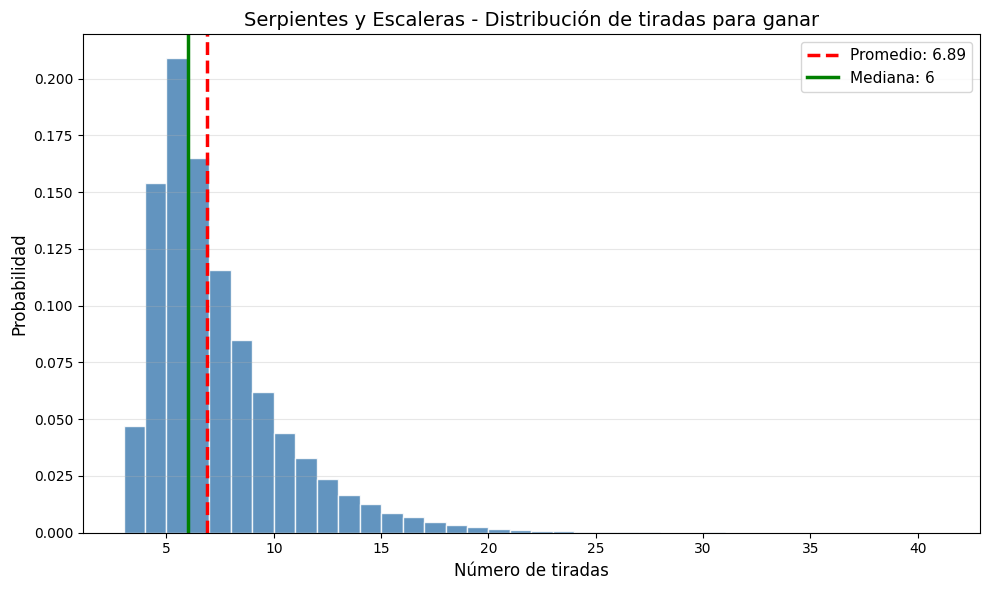

In [134]:
# --- Histograma ---
plt.figure(figsize=(10, 6))

plt.hist(resultados,
         bins=range(resultados.min(), resultados.max() + 2),
         edgecolor='white',
         color='steelblue',
         alpha=0.85,
         density=True)

# Línea del promedio
plt.axvline(promedio, color='red', linestyle='--',
            linewidth=2.5, label=f'Promedio: {promedio:.2f}')

# Línea de la mediana
plt.axvline(mediana, color='green', linestyle='-',
            linewidth=2.5, label=f'Mediana: {mediana:.0f}')

plt.xlabel('Número de tiradas', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title('Serpientes y Escaleras - Distribución de tiradas para ganar', fontsize=14)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


 ##  <span style="color:teal;">**Conclusión**</span>

En esta práctica se analizó el juego de serpientes y escaleras utilizando tanto un enfoque analítico como un método de simulación Monte Carlo. Mediante el modelado del tablero como una cadena de Markov y la formulación de ecuaciones de esperanza, fue posible determinar el número promedio de tiradas necesarias para finalizar el juego.

El número promedio de tiradas necesarias para completar el juego es aproximadamente **6.8983**.

 Este resultado fue obtenido mediante:
 1. **Cadenas de Markov absorbentes**: $6.8983≈7$ tiradas para terminar el juego (solución exacta)
 2. **Simulación Monte Carlo**: ~$6. 6.89≈7$ tiradas para terminar el juego (aproximación numérica)


los resultados obtenidos analíticamente se compararon con los obtenidos por simulación, observándose una gran similitud entre ambos valores. Esto permitió validar la correcta implementación de la simulación y comprobar que los métodos Monte Carlo pueden aproximar de manera eficiente resultados teóricos en problemas probabilísticos, validando el modelo matemático.